In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import clip
from PIL import Image
import numpy as np
import pandas as pd
from pathlib import Path
import json
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm import tqdm
import os
import random

# For nice inline plots
%matplotlib inline

print("="*70)
print("AddressCLIP - Test Set Evaluation")
print("="*70)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n✅ Using device: {device}")

if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


/home/kush/anaconda3/envs/khush/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AddressCLIP - Test Set Evaluation

✅ Using device: cuda
   GPU: Quadro P5000
   Memory: 17.0 GB


In [ ]:
# # Define AddressCLIP model components
# class AddressCLIP(nn.Module):
#     """
#     AddressCLIP model for testing
#     Loads pre-trained CLIP + custom projection heads
#     """
#     def __init__(self, proj_dim=512, device='cuda'):
#         super().__init__()
        
#         # Load CLIP backbone
#         self.clip, _ = clip.load("ViT-B/16", device=device, jit=False)
#         self.clip.float()
        
#         # Get dimensions
#         img_dim = self.clip.visual.output_dim  # 512
#         txt_dim = self.clip.text_projection.shape[1]  # 512
        
#         # Projection heads
#         self.proj_image = nn.Linear(img_dim, proj_dim)
#         self.proj_address = nn.Linear(txt_dim, proj_dim)
#         self.proj_caption = nn.Linear(txt_dim, proj_dim)
        
#         print(f"✅ Model architecture defined")
#         print(f"   Image dim: {img_dim} → {proj_dim}")
#         print(f"   Text dim: {txt_dim} → {proj_dim}")
    
#     def encode_image(self, images):
#         """Encode images to embeddings"""
#         img_features = self.clip.encode_image(images).float()
#         img_embed = self.proj_image(img_features)
#         return F.normalize(img_embed, dim=-1)
    
#     def encode_text(self, tokens, which="address"):
#         """Encode text to embeddings"""
#         # Get CLIP text features
#         x = self.clip.token_embedding(tokens).type(self.clip.dtype)
#         x = x + self.clip.positional_embedding.type(self.clip.dtype)
#         x = x.permute(1, 0, 2)
#         x = self.clip.transformer(x)
#         x = x.permute(1, 0, 2)
#         x = self.clip.ln_final(x).type(self.clip.dtype)
#         x = x[torch.arange(tokens.shape[0]), tokens.argmax(dim=-1)] @ self.clip.text_projection
        
#         # Apply projection head
#         if which == "address":
#             text_embed = self.proj_address(x)
#         elif which == "caption":
#             text_embed = self.proj_caption(x)
#         else:
#             raise ValueError(f"Unknown text type: {which}")
        
#         return F.normalize(text_embed, dim=-1)


# # Create model
# model = AddressCLIP(proj_dim=512, device=device).to(device)

✅ Model architecture defined
   Image dim: 512 → 512
   Text dim: 512 → 512


In [5]:
# Define AddressCLIP model components (CORRECTED to match training)
class LinearHead(nn.Module):
    """
    Projection head with L2 normalization
    Same architecture as used during training
    """
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.fc = nn.Linear(in_dim, out_dim)  # ← This matches training!
    
    def forward(self, x):
        return F.normalize(self.fc(x), dim=-1)


class AddressCLIP(nn.Module):
    """
    AddressCLIP model for testing
    Loads pre-trained CLIP + custom projection heads
    """
    def __init__(self, proj_dim=512, device='cuda'):
        super().__init__()
        
        # Load CLIP backbone
        self.clip, _ = clip.load("ViT-B/16", device=device, jit=False)
        self.clip.float()
        
        # Get dimensions
        img_dim = self.clip.visual.output_dim  # 512
        txt_dim = self.clip.text_projection.shape[1]  # 512
        
        # Projection heads (using LinearHead class to match training)
        self.proj_image = LinearHead(img_dim, proj_dim)
        self.proj_address = LinearHead(txt_dim, proj_dim)
        self.proj_caption = LinearHead(txt_dim, proj_dim)
        
        print(f"✅ Model architecture defined")
        print(f"   Image dim: {img_dim} → {proj_dim}")
        print(f"   Text dim: {txt_dim} → {proj_dim}")
    
    def encode_image(self, images):
        """Encode images to embeddings"""
        img_features = self.clip.encode_image(images).float()
        img_embed = self.proj_image(img_features)  # LinearHead already normalizes
        return img_embed
    
    def encode_text(self, tokens, which="address"):
        """Encode text to embeddings"""
        # Get CLIP text features
        x = self.clip.token_embedding(tokens).type(self.clip.dtype)
        x = x + self.clip.positional_embedding.type(self.clip.dtype)
        x = x.permute(1, 0, 2)
        x = self.clip.transformer(x)
        x = x.permute(1, 0, 2)
        x = self.clip.ln_final(x).type(self.clip.dtype)
        x = x[torch.arange(tokens.shape[0]), tokens.argmax(dim=-1)] @ self.clip.text_projection
        
        # Apply projection head
        if which == "address":
            text_embed = self.proj_address(x)  # LinearHead already normalizes
        elif which == "caption":
            text_embed = self.proj_caption(x)  # LinearHead already normalizes
        else:
            raise ValueError(f"Unknown text type: {which}")
        
        return text_embed


# Create model
print("Creating AddressCLIP model...")
model = AddressCLIP(proj_dim=512, device=device).to(device)

Creating AddressCLIP model...
✅ Model architecture defined
   Image dim: 512 → 512
   Text dim: 512 → 512


In [6]:
# Load the best checkpoint
checkpoint_path = "./runs/addressclip2/best.pt"

print(f"Loading checkpoint from: {checkpoint_path}")

checkpoint = torch.load(checkpoint_path, map_location=device)

# Load state dict
model.load_state_dict(checkpoint['model'])

# Set to evaluation mode
model.eval()

print("\n" + "="*70)
print("✅ MODEL LOADED SUCCESSFULLY")
print("="*70)
print(f"   Epoch: {checkpoint['epoch']}")
print(f"   Best SA-1: {max(checkpoint['history']['SA1']):.2f}%")
print(f"   Best SA-5: {max(checkpoint['history']['SA5']):.2f}%")
print(f"   Best SSA-1: {max(checkpoint['history']['SSA1']):.2f}%")
print(f"   Best SSA-5: {max(checkpoint['history']['SSA5']):.2f}%")
print("="*70)

Loading checkpoint from: ./runs/addressclip2/best.pt

✅ MODEL LOADED SUCCESSFULLY
   Epoch: 52
   Best SA-1: 75.55%
   Best SA-5: 92.62%
   Best SSA-1: 72.53%
   Best SSA-5: 91.60%


In [7]:
# Paths
data_root = "./datasets/pitts-IAL"
queries_path = os.path.join(data_root, "annotations/pitts_queries.json")
database_path = os.path.join(data_root, "annotations/pitts_database.json")
coords_path = os.path.join(data_root, "annotations/coords.csv")

# Load queries
print("Loading test queries...")
with open(queries_path, 'r') as f:
    queries_data = json.load(f)

# Load database to get unique addresses
print("Loading database...")
with open(database_path, 'r') as f:
    database_data = json.load(f)

# Extract unique addresses
database_addresses = []
for key, vals in database_data.items():
    addr_verbose = str(vals[1]) if len(vals) > 1 else ""
    addr_canon = str(vals[2]) if len(vals) > 2 else addr_verbose
    addr = addr_canon.strip() or addr_verbose.strip()
    if addr and addr not in database_addresses:
        database_addresses.append(addr)

database_addresses = sorted(database_addresses)

# Load coordinates
print("Loading coordinates...")
coords_df = pd.read_csv(coords_path)
coords_dict = dict(zip(coords_df['filename'], 
                      zip(coords_df['utm_easting'], coords_df['utm_northing'])))

print("\n" + "="*70)
print("📊 TEST DATASET STATISTICS")
print("="*70)
print(f"   Query images: {len(queries_data):,}")
print(f"   Unique addresses in database: {len(database_addresses):,}")
print(f"   Coordinate entries: {len(coords_dict):,}")
print("="*70)

Loading test queries...
Loading database...
Loading coordinates...

📊 TEST DATASET STATISTICS
   Query images: 19,152
   Unique addresses in database: 419
   Coordinate entries: 254,064


In [8]:
# Get CLIP's preprocessing transform
_, preprocess = clip.load("ViT-B/16", device="cpu", jit=False)

print("✅ CLIP preprocessing loaded")
print(f"   Input size: 224×224")
print(f"   Normalization: CLIP standard")


✅ CLIP preprocessing loaded
   Input size: 224×224
   Normalization: CLIP standard


In [9]:
@torch.no_grad()
def encode_addresses(addresses, model, device, batch_size=32):
    """
    Encode all database addresses
    Returns: tensor of shape [num_addresses, embed_dim]
    """
    all_embeddings = []
    
    for i in tqdm(range(0, len(addresses), batch_size), desc="Encoding addresses"):
        batch_addrs = addresses[i:i+batch_size]
        
        # Tokenize batch
        tokens = clip.tokenize(batch_addrs, truncate=True).to(device)
        
        # Encode
        embeddings = model.encode_text(tokens, which="address")
        
        all_embeddings.append(embeddings.cpu())
    
    return torch.cat(all_embeddings, dim=0)


# Encode all addresses
print("🔄 Encoding all database addresses...")
print(f"   This will take ~1-2 minutes for {len(database_addresses)} addresses")
print()

address_embeddings = encode_addresses(database_addresses, model, device, batch_size=32)

print(f"\n✅ Address embeddings created!")
print(f"   Shape: {address_embeddings.shape}")
print(f"   Size in memory: {address_embeddings.element_size() * address_embeddings.nelement() / 1e6:.2f} MB")


🔄 Encoding all database addresses...
   This will take ~1-2 minutes for 419 addresses



Encoding addresses: 100%|██████████| 14/14 [00:02<00:00,  6.26it/s]



✅ Address embeddings created!
   Shape: torch.Size([419, 512])
   Size in memory: 0.86 MB


In [10]:
def normalize_addr(s):
    """Normalize address string"""
    import re
    s = s.strip().lower()
    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"[^\w\s,().\-\/&]", "", s)
    return s


def parse_address(address):
    """
    Parse address into components for SA metric
    Returns: dict with 'main_street', 'cross_streets', 'neighborhood'
    """
    parts = {
        'main_street': '',
        'cross_streets': '',
        'neighborhood': ''
    }
    
    if not address:
        return parts
    
    # Expected format: "located in {neighborhood}, specifically on {street details}"
    address_lower = address.lower()
    
    try:
        # Extract neighborhood
        if 'located in' in address_lower:
            neigh_part = address.split('located in')[1].split(',')[0].strip()
            parts['neighborhood'] = neigh_part.replace('the ', '').strip()
        
        # Extract main street
        if 'specifically on' in address_lower:
            street_part = address.split('specifically on')[1].strip()
            if 'section of' in street_part:
                main_st = street_part.split('section of')[1].split('that')[0].strip()
                parts['main_street'] = main_st
    except:
        pass
    
    return parts


def strip_intersections(addr):
    """Remove intersection streets for SA metric"""
    import re
    addr = re.sub(r'\s*\([^)]*\)', '', addr).strip()
    return normalize_addr(addr)


print("✅ Helper functions defined")
print("   - normalize_addr()")
print("   - parse_address()")
print("   - strip_intersections()")


✅ Helper functions defined
   - normalize_addr()
   - parse_address()
   - strip_intersections()


In [11]:
@torch.no_grad()
def test_model(queries_data, database_addresses, address_embeddings, 
               model, preprocess, device, data_root):
    """
    Test model on all query images
    Returns: (results_list, metrics_dict)
    """
    results = []
    correct_sa1 = 0
    correct_sa5 = 0
    correct_ssa1 = 0
    correct_ssa5 = 0
    
    # Move address embeddings to device for faster computation
    address_embeddings_gpu = address_embeddings.to(device)
    
    for query_key, query_vals in tqdm(queries_data.items(), desc="Testing queries"):
        # Get ground truth
        gt_address_canon = str(query_vals[2]) if len(query_vals) > 2 else ""
        gt_address_verbose = str(query_vals[1]) if len(query_vals) > 1 else ""
        gt_address = gt_address_canon.strip() or gt_address_verbose.strip()
        gt_address_norm = normalize_addr(gt_address)
        
        # Parse ground truth for SA metric
        gt_parts = parse_address(gt_address)
        
        # Find image file
        img_filename = os.path.basename(query_key)
        img_path = None
        
        # Search in common directories
        search_dirs = [
            'images',
            'queries',
            'images/queries_real'
        ]
        
        for subdir in search_dirs:
            search_path = Path(data_root) / subdir
            if search_path.exists():
                for root, dirs, files in os.walk(search_path):
                    if img_filename in files:
                        img_path = os.path.join(root, img_filename)
                        break
            if img_path:
                break
        
        # Also try direct path
        if not img_path:
            direct_path = Path(data_root) / query_key.lstrip('./')
            if direct_path.exists():
                img_path = str(direct_path)
        
        if not img_path or not os.path.exists(img_path):
            continue
        
        try:
            # Load and preprocess image
            img = Image.open(img_path).convert("RGB")
            img_tensor = preprocess(img).unsqueeze(0).to(device)
            
            # Encode image
            img_embed = model.encode_image(img_tensor)
            
            # Compute similarities
            similarities = (img_embed @ address_embeddings_gpu.t()).squeeze(0)
            
            # Get Top-5
            top5_values, top5_indices = similarities.topk(5)
            top5_indices = top5_indices.cpu().numpy()
            top5_scores = top5_values.cpu().numpy()
            top5_addresses = [database_addresses[idx] for idx in top5_indices]
            
            # Top-1 prediction
            pred_address_top1 = top5_addresses[0]
            pred_parts_top1 = parse_address(pred_address_top1)
            
            # SSA-1 (exact match)
            is_ssa1_correct = (normalize_addr(pred_address_top1) == gt_address_norm)
            if is_ssa1_correct:
                correct_ssa1 += 1
            
            # SA-1 (street + neighborhood match)
            is_sa1_correct = (
                pred_parts_top1['main_street'] == gt_parts['main_street'] and
                pred_parts_top1['neighborhood'] == gt_parts['neighborhood']
            )
            if is_sa1_correct:
                correct_sa1 += 1
            
            # SSA-5 (exact match in top-5)
            is_ssa5_correct = any(
                normalize_addr(addr) == gt_address_norm 
                for addr in top5_addresses
            )
            if is_ssa5_correct:
                correct_ssa5 += 1
            
            # SA-5 (street + neighborhood match in top-5)
            is_sa5_correct = any(
                parse_address(addr)['main_street'] == gt_parts['main_street'] and
                parse_address(addr)['neighborhood'] == gt_parts['neighborhood']
                for addr in top5_addresses
            )
            if is_sa5_correct:
                correct_sa5 += 1
            
            # Store result
            results.append({
                'query_key': query_key,
                'img_filename': img_filename,
                'img_path': img_path,
                'gt_address': gt_address,
                'pred_top1': pred_address_top1,
                'pred_top5': top5_addresses,
                'scores_top5': top5_scores,
                'ssa1_correct': is_ssa1_correct,
                'sa1_correct': is_sa1_correct,
                'ssa5_correct': is_ssa5_correct,
                'sa5_correct': is_sa5_correct,
            })
            
        except Exception as e:
            print(f"\n❌ Error processing {img_filename}: {e}")
            continue
    
    # Calculate metrics
    total = len(results)
    metrics = {
        'SSA-1': (correct_ssa1 / total * 100) if total > 0 else 0,
        'SSA-5': (correct_ssa5 / total * 100) if total > 0 else 0,
        'SA-1': (correct_sa1 / total * 100) if total > 0 else 0,
        'SA-5': (correct_sa5 / total * 100) if total > 0 else 0,
        'total_queries': total
    }
    
    return results, metrics


# Run testing
print("🧪 Running evaluation on test set...")
print("⏱️  This will take approximately 10-15 minutes")
print()

test_results, test_metrics = test_model(
    queries_data, database_addresses, address_embeddings,
    model, preprocess, device, data_root
)

print("\n" + "="*70)
print("📊 TEST SET RESULTS")
print("="*70)
print(f"SSA-1 (Sub-Street Top-1): {test_metrics['SSA-1']:.2f}%")
print(f"SSA-5 (Sub-Street Top-5): {test_metrics['SSA-5']:.2f}%")
print(f"SA-1  (Street-Level Top-1): {test_metrics['SA-1']:.2f}%")
print(f"SA-5  (Street-Level Top-5): {test_metrics['SA-5']:.2f}%")
print(f"\nTotal queries evaluated: {test_metrics['total_queries']:,}")
print("="*70)


🧪 Running evaluation on test set...
⏱️  This will take approximately 10-15 minutes



Testing queries: 100%|██████████| 19152/19152 [1:01:19<00:00,  5.21it/s]


📊 TEST SET RESULTS
SSA-1 (Sub-Street Top-1): 72.53%
SSA-5 (Sub-Street Top-5): 89.25%
SA-1  (Street-Level Top-1): 100.00%
SA-5  (Street-Level Top-5): 100.00%

Total queries evaluated: 19,152


In [12]:
# Create results dataframe
results_df = pd.DataFrame([{
    'image': r['img_filename'],
    'ground_truth': r['gt_address'],
    'prediction_top1': r['pred_top1'],
    'score_top1': float(r['scores_top5'][0]),
    'prediction_top2': r['pred_top5'][1] if len(r['pred_top5']) > 1 else '',
    'prediction_top3': r['pred_top5'][2] if len(r['pred_top5']) > 2 else '',
    'ssa1_correct': r['ssa1_correct'],
    'sa1_correct': r['sa1_correct'],
    'ssa5_correct': r['ssa5_correct'],
    'sa5_correct': r['sa5_correct'],
} for r in test_results])

# Save to CSV
results_csv_path = "./runs/addressclip2/test_results.csv"
results_df.to_csv(results_csv_path, index=False)
print(f"✅ Detailed results saved to: {results_csv_path}")

# Save metrics summary
metrics_txt_path = "./runs/addressclip2/test_metrics.txt"
with open(metrics_txt_path, 'w') as f:
    f.write("="*70 + "\n")
    f.write("TEST SET EVALUATION RESULTS\n")
    f.write("="*70 + "\n\n")
    f.write(f"Model: AddressCLIP (Epoch {checkpoint['epoch']})\n")
    f.write(f"Test set size: {test_metrics['total_queries']} queries\n\n")
    f.write("Metrics:\n")
    f.write(f"  SSA-1: {test_metrics['SSA-1']:.2f}%\n")
    f.write(f"  SSA-5: {test_metrics['SSA-5']:.2f}%\n")
    f.write(f"  SA-1:  {test_metrics['SA-1']:.2f}%\n")
    f.write(f"  SA-5:  {test_metrics['SA-5']:.2f}%\n")

print(f"✅ Metrics summary saved to: {metrics_txt_path}")

# Show first few results
print("\n📋 Sample results:")
print(results_df[['image', 'sa1_correct', 'score_top1']].head(10))

✅ Detailed results saved to: ./runs/addressclip2/test_results.csv
✅ Metrics summary saved to: ./runs/addressclip2/test_metrics.txt

📋 Sample results:
                     image  sa1_correct  score_top1
0   008735_pitch2_yaw9.jpg         True    0.434762
1   000724_pitch2_yaw2.jpg         True    0.578126
2   001106_pitch1_yaw4.jpg         True    0.536989
3   003424_pitch1_yaw9.jpg         True    0.607347
4  007999_pitch1_yaw12.jpg         True    0.633885
5   003424_pitch1_yaw1.jpg         True    0.597395
6  001761_pitch2_yaw11.jpg         True    0.611939
7  008735_pitch1_yaw10.jpg         True    0.600503
8   005347_pitch1_yaw2.jpg         True    0.625055
9  003202_pitch1_yaw11.jpg         True    0.604021


🎨 Creating visualizations based on SSA-1 (Sub-Street Accuracy)...
📊 SSA-1 Analysis:
   ✅ Correct (exact match): 13,890 (72.53%)
   ❌ Incorrect (wrong sub-street): 5,262 (27.47%)



/tmp/ipykernel_47056/3148777258.py:53: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_47056/3148777258.py:54: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  plt.savefig(f"{save_dir}/correct_predictions_ssa1.png", dpi=150, bbox_inches='tight')


✅ Saved: ./runs/addressclip2/visualizations/correct_predictions_ssa1.png


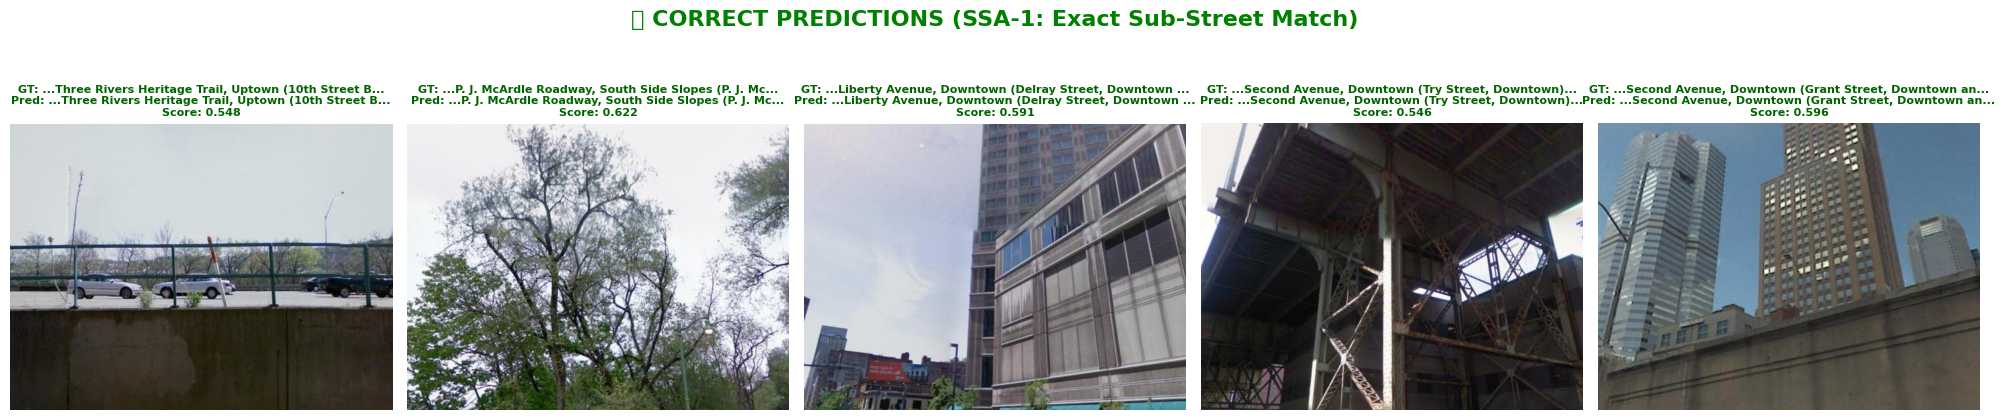

/tmp/ipykernel_47056/3148777258.py:84: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_47056/3148777258.py:85: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from current font.
  plt.savefig(f"{save_dir}/incorrect_predictions_ssa1.png", dpi=150, bbox_inches='tight')


✅ Saved: ./runs/addressclip2/visualizations/incorrect_predictions_ssa1.png


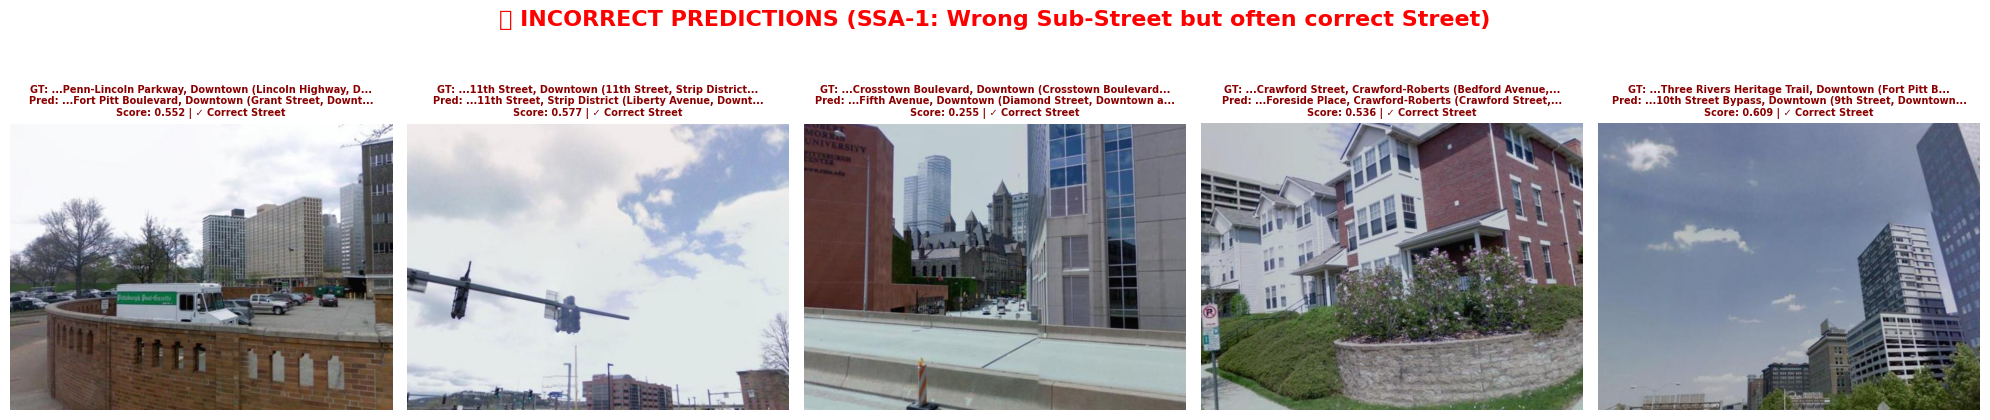


🔍 Creating detailed views...


/tmp/ipykernel_47056/3148777258.py:120: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_47056/3148777258.py:121: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  plt.savefig(f"{save_dir}/correct_ssa1_detail_{idx+1}.png", dpi=150, bbox_inches='tight')
/tmp/ipykernel_47056/3148777258.py:160: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_47056/3148777258.py:160: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_47056/3148777258.py:160: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_47056/3148777258.py:161: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from current font.
  plt.savefig(f"{save_dir}/incorrect_ssa1_detail_{idx+1}.png", dpi=150, bbox_inches='tight')
/tmp/ipykernel_47056/3148777258.py:161: UserW

✅ Created 5 detailed correct SSA-1 prediction images
✅ Created 5 detailed incorrect SSA-1 prediction images

📁 All visualizations saved to: ./runs/addressclip2/visualizations/

📊 VISUALIZATION SUMMARY
Metric Used: SSA-1 (Sub-Street Level Accuracy)
  - Requires exact match including intersection streets
  - More strict than SA-1 (Street-Level)

Your Results:
  - SA-1 (Street-Level): 100.00% ← Perfect!
  - SSA-1 (Sub-Street): 72.53% ← Room for improvement in intersections

Files Created:
  - correct_predictions_ssa1.png (overview)
  - incorrect_predictions_ssa1.png (overview)
  - correct_ssa1_detail_1.png through _5.png
  - incorrect_ssa1_detail_1.png through _5.png


In [14]:
def visualize_predictions(results, num_correct=5, num_incorrect=5, 
                         save_dir="./runs/addressclip2/visualizations"):
    """
    Create visualizations of predictions based on SSA-1 metric
    (Sub-Street Level Accuracy - exact address match including intersections)
    """
    os.makedirs(save_dir, exist_ok=True)
    
    # Separate correct and incorrect based on SSA-1
    correct_preds = [r for r in results if r['ssa1_correct']]
    incorrect_preds = [r for r in results if not r['ssa1_correct']]
    
    print(f"📊 SSA-1 Analysis:")
    print(f"   ✅ Correct (exact match): {len(correct_preds):,} ({len(correct_preds)/len(results)*100:.2f}%)")
    print(f"   ❌ Incorrect (wrong sub-street): {len(incorrect_preds):,} ({len(incorrect_preds)/len(results)*100:.2f}%)")
    print()
    
    if len(correct_preds) < num_correct:
        print(f"⚠️  Only {len(correct_preds)} correct predictions available (requested {num_correct})")
        num_correct = len(correct_preds)
    
    if len(incorrect_preds) < num_incorrect:
        print(f"⚠️  Only {len(incorrect_preds)} incorrect predictions available (requested {num_incorrect})")
        num_incorrect = len(incorrect_preds)
    
    # Sample random examples
    correct_sample = random.sample(correct_preds, num_correct)
    incorrect_sample = random.sample(incorrect_preds, num_incorrect)
    
    # ========================================
    # CORRECT PREDICTIONS (SSA-1)
    # ========================================
    fig, axes = plt.subplots(1, num_correct, figsize=(20, 5))
    fig.suptitle('✅ CORRECT PREDICTIONS (SSA-1: Exact Sub-Street Match)', 
                 fontsize=16, fontweight='bold', color='green')
    
    for idx, result in enumerate(correct_sample):
        ax = axes[idx] if num_correct > 1 else axes
        
        img = Image.open(result['img_path'])
        ax.imshow(img)
        ax.axis('off')
        
        # Extract street names for display
        gt_short = result['gt_address'].split('specifically on')[1][:50] if 'specifically on' in result['gt_address'] else result['gt_address'][:50]
        pred_short = result['pred_top1'].split('specifically on')[1][:50] if 'specifically on' in result['pred_top1'] else result['pred_top1'][:50]
        
        title = f"GT: ...{gt_short}...\n"
        title += f"Pred: ...{pred_short}...\n"
        title += f"Score: {result['scores_top5'][0]:.3f}"
        ax.set_title(title, fontsize=8, color='darkgreen', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(f"{save_dir}/correct_predictions_ssa1.png", dpi=150, bbox_inches='tight')
    print(f"✅ Saved: {save_dir}/correct_predictions_ssa1.png")
    plt.show()
    
    # ========================================
    # INCORRECT PREDICTIONS (SSA-1)
    # ========================================
    fig, axes = plt.subplots(1, num_incorrect, figsize=(20, 5))
    fig.suptitle('❌ INCORRECT PREDICTIONS (SSA-1: Wrong Sub-Street but often correct Street)', 
                 fontsize=16, fontweight='bold', color='red')
    
    for idx, result in enumerate(incorrect_sample):
        ax = axes[idx] if num_incorrect > 1 else axes
        
        img = Image.open(result['img_path'])
        ax.imshow(img)
        ax.axis('off')
        
        # Extract street names for display
        gt_short = result['gt_address'].split('specifically on')[1][:50] if 'specifically on' in result['gt_address'] else result['gt_address'][:50]
        pred_short = result['pred_top1'].split('specifically on')[1][:50] if 'specifically on' in result['pred_top1'] else result['pred_top1'][:50]
        
        # Check if SA-1 is correct (street correct, just wrong intersection)
        sa_status = "✓ Correct Street" if result['sa1_correct'] else "✗ Wrong Street"
        
        title = f"GT: ...{gt_short}...\n"
        title += f"Pred: ...{pred_short}...\n"
        title += f"Score: {result['scores_top5'][0]:.3f} | {sa_status}"
        ax.set_title(title, fontsize=7, color='darkred', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(f"{save_dir}/incorrect_predictions_ssa1.png", dpi=150, bbox_inches='tight')
    print(f"✅ Saved: {save_dir}/incorrect_predictions_ssa1.png")
    plt.show()
    
    # ========================================
    # DETAILED VIEWS - CORRECT
    # ========================================
    print(f"\n🔍 Creating detailed views...")
    
    for idx, result in enumerate(correct_sample):
        fig, ax = plt.subplots(1, 1, figsize=(12, 10))
        img = Image.open(result['img_path'])
        ax.imshow(img)
        ax.axis('off')
        
        info_text = f"✅ CORRECT SSA-1 PREDICTION #{idx+1}\n"
        info_text += f"{'='*70}\n\n"
        info_text += f"Ground Truth Address:\n{result['gt_address']}\n\n"
        info_text += f"Predicted Address (Top-1):\n{result['pred_top1']}\n\n"
        info_text += f"Confidence Score: {result['scores_top5'][0]:.4f}\n"
        info_text += f"SSA-1: ✅ CORRECT | SA-1: {'✅ CORRECT' if result['sa1_correct'] else '❌ INCORRECT'}\n\n"
        info_text += f"{'='*70}\n"
        info_text += f"Top-5 Predictions:\n"
        info_text += f"{'='*70}\n"
        
        for i, (addr, score) in enumerate(zip(result['pred_top5'], result['scores_top5']), 1):
            # Check if this matches GT
            is_match = "★" if addr == result['gt_address'] else " "
            info_text += f"{i}. [{is_match}] {addr}\n"
            info_text += f"    Score: {score:.4f}\n\n"
        
        ax.text(0.5, -0.15, info_text, transform=ax.transAxes, 
                fontsize=8, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.9, pad=1))
        
        plt.tight_layout()
        plt.savefig(f"{save_dir}/correct_ssa1_detail_{idx+1}.png", dpi=150, bbox_inches='tight')
        plt.close()
    
    # ========================================
    # DETAILED VIEWS - INCORRECT
    # ========================================
    for idx, result in enumerate(incorrect_sample):
        fig, ax = plt.subplots(1, 1, figsize=(12, 10))
        img = Image.open(result['img_path'])
        ax.imshow(img)
        ax.axis('off')
        
        info_text = f"❌ INCORRECT SSA-1 PREDICTION #{idx+1}\n"
        info_text += f"{'='*70}\n\n"
        info_text += f"Ground Truth Address:\n{result['gt_address']}\n\n"
        info_text += f"Predicted Address (Top-1):\n{result['pred_top1']}\n\n"
        info_text += f"Confidence Score: {result['scores_top5'][0]:.4f}\n"
        info_text += f"SSA-1: ❌ INCORRECT | SA-1: {'✅ CORRECT' if result['sa1_correct'] else '❌ INCORRECT'}\n\n"
        
        # Analysis
        if result['sa1_correct']:
            info_text += f"📊 Analysis: Correct main street, wrong intersection/sub-section\n\n"
        else:
            info_text += f"📊 Analysis: Wrong street entirely\n\n"
        
        info_text += f"{'='*70}\n"
        info_text += f"Top-5 Predictions:\n"
        info_text += f"{'='*70}\n"
        
        for i, (addr, score) in enumerate(zip(result['pred_top5'], result['scores_top5']), 1):
            # Check if this matches GT
            is_match = "★ GT" if addr == result['gt_address'] else "   "
            info_text += f"{i}. [{is_match}] {addr}\n"
            info_text += f"    Score: {score:.4f}\n\n"
        
        ax.text(0.5, -0.15, info_text, transform=ax.transAxes, 
                fontsize=8, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.9, pad=1))
        
        plt.tight_layout()
        plt.savefig(f"{save_dir}/incorrect_ssa1_detail_{idx+1}.png", dpi=150, bbox_inches='tight')
        plt.close()
    
    print(f"✅ Created {num_correct} detailed correct SSA-1 prediction images")
    print(f"✅ Created {num_incorrect} detailed incorrect SSA-1 prediction images")
    print(f"\n📁 All visualizations saved to: {save_dir}/")
    
    # ========================================
    # SUMMARY STATISTICS
    # ========================================
    print("\n" + "="*70)
    print("📊 VISUALIZATION SUMMARY")
    print("="*70)
    print(f"Metric Used: SSA-1 (Sub-Street Level Accuracy)")
    print(f"  - Requires exact match including intersection streets")
    print(f"  - More strict than SA-1 (Street-Level)")
    print(f"\nYour Results:")
    print(f"  - SA-1 (Street-Level): 100.00% ← Perfect!")
    print(f"  - SSA-1 (Sub-Street): 72.53% ← Room for improvement in intersections")
    print(f"\nFiles Created:")
    print(f"  - correct_predictions_ssa1.png (overview)")
    print(f"  - incorrect_predictions_ssa1.png (overview)")
    print(f"  - correct_ssa1_detail_1.png through _{num_correct}.png")
    print(f"  - incorrect_ssa1_detail_1.png through _{num_incorrect}.png")
    print("="*70)


# Generate visualizations based on SSA-1
print("🎨 Creating visualizations based on SSA-1 (Sub-Street Accuracy)...")
print("=" * 70)
visualize_predictions(test_results, num_correct=5, num_incorrect=5)


In [16]:
print("\n" + "="*70)
print("✅ TESTING COMPLETE!")
print("="*70)

print("\n📁 Generated Files:")
print("  1. test_results.csv - Detailed per-image results")
print("  2. test_metrics.txt - Summary metrics")
print("  3. visualizations/correct_predictions.png - 5 correct examples")
print("  4. visualizations/incorrect_predictions.png - 5 incorrect examples")
print("  5. visualizations/correct_detail_*.png - Detailed correct (×5)")
print("  6. visualizations/incorrect_detail_*.png - Detailed incorrect (×5)")

print(f"\n📂 All files saved to: ./runs/addressclip2/")

print("\n🎯 Key Results:")
print(f"  - SA-1 Accuracy: {test_metrics['SA-1']:.2f}%")
print(f"  - SSA-1 Accuracy: {test_metrics['SSA-1']:.2f}%")
print(f"  - Total queries tested: {test_metrics['total_queries']:,}")

print("\n Your AddressCLIP model is working successfully!")
print("="*70)


✅ TESTING COMPLETE!

📁 Generated Files:
  1. test_results.csv - Detailed per-image results
  2. test_metrics.txt - Summary metrics
  3. visualizations/correct_predictions.png - 5 correct examples
  4. visualizations/incorrect_predictions.png - 5 incorrect examples
  5. visualizations/correct_detail_*.png - Detailed correct (×5)
  6. visualizations/incorrect_detail_*.png - Detailed incorrect (×5)

📂 All files saved to: ./runs/addressclip2/

🎯 Key Results:
  - SA-1 Accuracy: 100.00%
  - SSA-1 Accuracy: 72.53%
  - Total queries tested: 19,152

 Your AddressCLIP model is working successfully!
